In [2]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

# Load the data

In [3]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [4]:
y.shape, tx.shape

((10000,), (10000, 2))

In [5]:
#test parameters
w=np.array([1, 2]).T
w.shape


(2,)

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [ ]:
# answer 1: The first X column represents the bias, i.e. the origin ordinate, while the second column represent the first covariate or indipendent variable, which in this case it'only one 
# and represents the height. Indeed, in this case we consider that a person weight, i.e the dependent variable y, is related to a person height through a linear relation, so y is approximately equal to 
# w0 + w1*x. We have a sample of 10000 people and we want to estimate the parameters the two parameters (w0, w1) in order to make predictions on a new sample and/or understand how much 
# the height impacts on a person weight. 

In [ ]:
# answer 2: Each row of X represents a different sample element, so a different person's data.

In [ ]:
# answer 3: look answer 1.

In [ ]:
#answer 4: y.shape=(3, ) ; X.shape=(3, 2); X_{3, 2}= the height of the 3rd person.

In [6]:
def compute_loss(y, tx, w, MSE=True):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    #sample size
    N=len(y)

    
    #compute the error matrix
    e=y- tx @ w 
    
    
    
    if MSE :
    # compute the MSE loss or MAE loss
        Lw= (0.5*N)*(e @ e) #e.T @ e
    else :
        #Lw= (1/N) * (np.sum(np.sum ( np.abs(e.reshape(-1, 1)) , axis=1), axis=0))
        Lw=(1/N) * sum(abs(e))

    return Lw
    

In [7]:
L=compute_loss(y, tx, w, False)
print(L)

72.29392200210516


# 2. Grid Search

Fill in the function `grid_search()` below:

In [8]:
#from costs import *


def grid_search(y, tx, grid_w0, grid_w1, MSE=True):
    """Algorithm for grid search.

    Args:
    
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1))) 

    for i in range(len(grid_w0)):
        for j in range (len(grid_w1)):
            w=np.array([grid_w0[i], grid_w1[j]])
            losses[i, j]= compute_loss(y, tx, w, MSE) 
        
   
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=1775784652.3990552, w0*=71.91011235955054, w1*=11.797752808988747, execution time=0.369 seconds


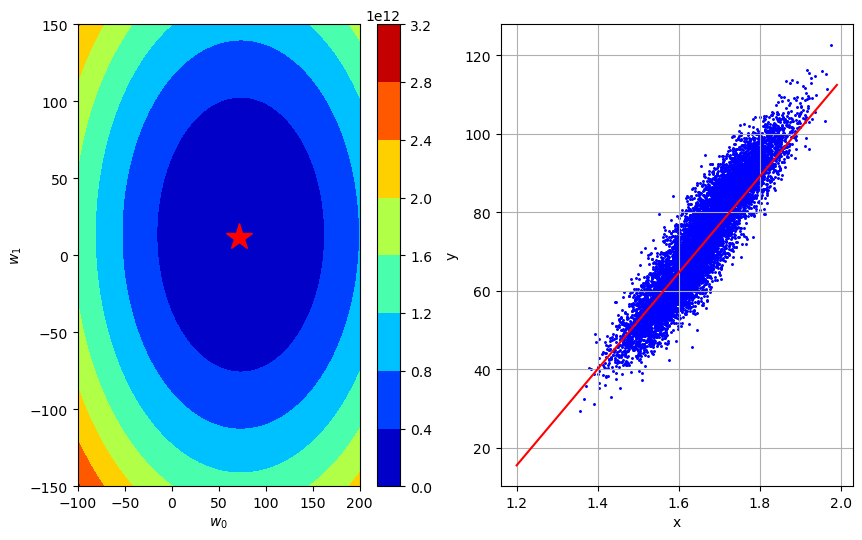

In [9]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization



# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=90)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

In [ ]:
# answer: we observe that the computational time increases proportionally to num_intervals, however even if the loss diminishes when we increaes num_interval, the improvement is not much relevant after a certain num_intervals.
# for example if n=80 time=0.34s loss=1.64e9, n=120 time=0.436 loss=1.57e9, n=400 loss=1.55e9 time=5.5s

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [10]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    
    #sample size
    N=len(y)

    #compute error
    e=y - tx @ w

    #compute gradient
    grad=(-1/N)* (tx.T @ e)

    return grad

In [11]:
#test
X=np.array([[1 ,3],[1, 5] ])
yy=np.array([6, 4])
ww=np.array([2, 2])
grad= compute_gradient(yy, X, ww)
print(grad)


[ 5. 23.]


In [12]:
#test 2
w_1=np.array([100, 20])
w_2=np.array([50, 10])
grad=compute_gradient(y, tx, w_1)
print(grad)
grad=compute_gradient(y, tx, w_2)
print(grad)

[26.706078    6.52028757]
[-23.293922    -3.47971243]


In [ ]:
#answer question b)
# a quadratic function is convex, therefore has a global minimum, therefore, when we are near that point, the norm of the gradient is near zero. so the gradient values 
# computed above tell us that we are far from the w* =argmin L(w). the gradient descendent and related algorithms use the gradient direction to reach the argmin

Please fill in the functions `gradient_descent` below:

In [13]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        
        # computing gradient and loss
       
        grad=compute_gradient(y, tx, w)
        loss=compute_loss(y, tx, w)
        
        # update w by gradient
        w = w - gamma * grad

        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [24]:
# from gradient_descent import *
from plots import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1

# Initialization
w_initial = np.array([100, 10])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=37804738819.87589, w0=97.32939220021052, w1=10.347971243498911
GD iter. 1/49: loss=30914170313.60723, w0=94.92584518039999, w1=10.661145362647925
GD iter. 2/49: loss=25332809823.529617, w0=92.7626528625705, w1=10.943002069882041
GD iter. 3/49: loss=20811907826.566742, w0=90.81577977652397, w1=11.196673106392746
GD iter. 4/49: loss=17149977209.02681, w0=89.06359399908209, w1=11.424977039252378
GD iter. 5/49: loss=14183813408.819468, w0=87.4866267993844, w1=11.630450578826046
GD iter. 6/49: loss=11781220730.65153, w0=86.06735631965648, w1=11.815376764442348
GD iter. 7/49: loss=9835120661.335505, w0=84.79001288790136, w1=11.981810331497023
GD iter. 8/49: loss=8258779605.189516, w0=83.64040379932173, w1=12.131600541846227
GD iter. 9/49: loss=6981943349.711262, w0=82.60575561960007, w1=12.26641173116051
GD iter. 10/49: loss=5947705982.773877, w0=81.67457225785058, w1=12.387741801543365
GD iter. 11/49: loss=5109973715.554598, w0=80.83650723227605, w1=12.496938864887936
GD

In [ ]:
# the cost function is going down, so it seems it's being minimized. it doesn't seem very quick, since the loss diminishes very little between the 24 iteration and the last one.
# probably gamma is not the optimum.

In [ ]:
# Time Visualization
from ipywidgets import IntSlider, interact

def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

# 4. Stochastic gradient descent

In [30]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """
    # implement stochastic gradient computation. It's the same as the usual gradient.

    # batch size
    B=len(y)

    #compute error
    e=y - tx @ w

    #compute gradient
    grad=(-1/B)* (tx.T @ e)

    return grad
    
   


def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):

       

       #compute current loss
       loss= compute_loss(y, tx, w)
       
       # compute gradient and update w
       for minibatch_y, minibatch_tx in batch_iter(y, tx, batch_size):
                grad= compute_stoch_gradient(minibatch_y, minibatch_tx, w)
                w = w - gamma*grad
                
       # store w and loss
       ws.append(w)
       losses.append(loss)
        
       print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [31]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=279223671275.9167, w0=6.4429378558970924, w1=-4.518951896392679
SGD iter. 1/49: loss=241188888738.39877, w0=14.855528989535816, w1=3.4280781645060374
SGD iter. 2/49: loss=177342645256.83615, w0=21.932117642754683, w1=13.256752920872728
SGD iter. 3/49: loss=133442821686.5395, w0=26.825023170415882, w1=9.564247229749784
SGD iter. 4/49: loss=110273060107.04367, w0=31.504685548745776, w1=10.550345602678656
SGD iter. 5/49: loss=89284662456.53409, w0=35.702823281129014, w1=18.408019941793086
SGD iter. 6/49: loss=73407534683.47284, w0=39.50002884850089, w1=21.111665298747987
SGD iter. 7/49: loss=61552284736.47606, w0=41.300791825099004, w1=23.060464177191385
SGD iter. 8/49: loss=57306147910.31182, w0=42.95642265077551, w1=23.307257239337353
SGD iter. 9/49: loss=52385813975.553085, w0=46.648703415508706, w1=24.55571768921848
SGD iter. 10/49: loss=43170867082.84421, w0=49.02142519166748, w1=25.01022677722163
SGD iter. 11/49: loss=37643931907.33997, w0=53.95720282951396, w1=

In [32]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 5. Effect of Outliers and MAE Cost Function

In [52]:
import datetime
from helpers import *

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: reload the data by subsampling first, then by subsampling and adding outliers
# ***************************************************

# subsampling
height_1, weight_1, gender_1 = load_data(sub_sample=True, add_outlier=True)
x_1, mean_x_1, std_x_1 = standardize(height_1)
y_1, tx_1 = build_model_data(x_1, weight_1)



In [53]:
y_1.shape, tx_1.shape

((204,), (204, 2))

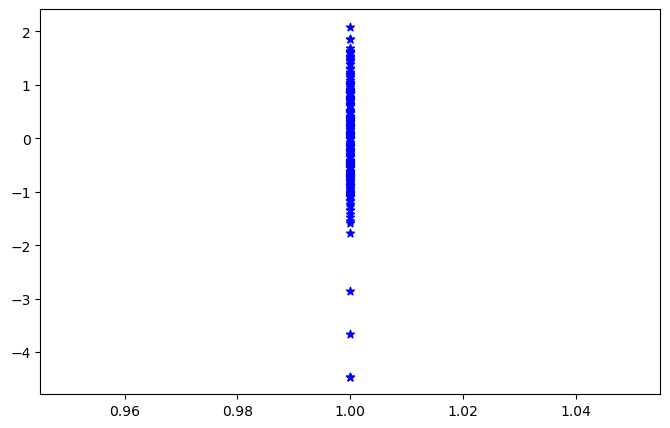

In [54]:
# plot data
plt.figure(figsize=(8,5))
plt.scatter(tx_1[:, 0], tx_1[:, 1], color="blue", marker="*")

In [55]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: fit the model to the subsampled data / subsampled data with outliers and visualize the cloud of points
#       and the model fit
# ***************************************************
gd_losses_1, gd_ws_1 = gradient_descent(y_1, tx_1, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=121700901.1990521, w0=52.230254357136, w1=5.748800086991227
GD iter. 1/49: loss=15004533.356927507, w0=67.89933066427685, w1=7.473440113088602
GD iter. 2/49: loss=5401860.251136246, w0=72.6000535564191, w1=7.990832120917821
GD iter. 3/49: loss=4537619.6716150325, w0=74.01027042406177, w1=8.14604972326659
GD iter. 4/49: loss=4459838.019458123, w0=74.43333548435457, w1=8.192615003971218
GD iter. 5/49: loss=4452837.670764001, w0=74.56025500244242, w1=8.20658458818261
GD iter. 6/49: loss=4452207.639381532, w0=74.59833085786877, w1=8.210775463446028
GD iter. 7/49: loss=4452150.936557109, w0=74.60975361449668, w1=8.21203272602505
GD iter. 8/49: loss=4452145.8333029095, w0=74.61318044148506, w1=8.212409904798756
GD iter. 9/49: loss=4452145.374010033, w0=74.61420848958156, w1=8.21252305843087
GD iter. 10/49: loss=4452145.332673673, w0=74.61451690401051, w1=8.212557004520503
GD iter. 11/49: loss=4452145.328953401, w0=74.6146094283392, w1=8.212567188347395
GD iter. 12/49: los

In [56]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses_1,
        gd_ws_1,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x_1,
        std_x_1,
        height_1,
        weight_1,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 6. Subgradient descent

In [60]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """

    # sample size
    N = len(y)

    grad=np.zeros(len(w))

    for i in range(N) : 
        Ln= y[i] - tx[i, :] @ w

        if Ln > 0 : 
            grad= grad - tx[i, :].T
        elif Ln < 0 : 
            grad = grad + tx[i, :].T
        else : #Ln ==0
            grad= grad - 0.5 * tx[i, :].T 


    return grad * (1/N)
    

In [61]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        # compute subgradient and loss
        
        loss= compute_loss(y, tx, w, False)
        grad= compute_subgradient_mae(y, tx, w)
        
        # update w by subgradient
        w = w - gamma * grad

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [62]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=73.29392200210475, w0=0.7, w1=-1.5529755259535704e-15
SubGD iter. 1/499: loss=72.59392200210564, w0=1.4, w1=-3.1059510519071408e-15
SubGD iter. 2/499: loss=71.89392200210507, w0=2.0999999999999996, w1=-4.658926577860711e-15
SubGD iter. 3/499: loss=71.19392200210523, w0=2.8, w1=-6.2119021038142816e-15
SubGD iter. 4/499: loss=70.49392200210522, w0=3.5, w1=-7.764877629767851e-15
SubGD iter. 5/499: loss=69.79392200210475, w0=4.2, w1=-9.317853155721422e-15
SubGD iter. 6/499: loss=69.0939220021055, w0=4.9, w1=-1.0870828681674993e-14
SubGD iter. 7/499: loss=68.39392200210523, w0=5.6000000000000005, w1=-1.2423804207628563e-14
SubGD iter. 8/499: loss=67.69392200210548, w0=6.300000000000001, w1=-1.3976779733582134e-14
SubGD iter. 9/499: loss=66.99392200210534, w0=7.000000000000001, w1=-1.5529755259535703e-14
SubGD iter. 10/499: loss=66.29392200210484, w0=7.700000000000001, w1=-1.7082730785489272e-14
SubGD iter. 11/499: loss=65.5939220021055, w0=8.4, w1=-1.863570631144284e

In [63]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [ ]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):

        #compute current MAE loss
        loss= compute_loss(y, tx, w, False)
       
       # compute gradient and update w
        for minibatch_y, minibatch_tx in batch_iter(y, tx, batch_size):
                grad= compute_subgradient_mae(minibatch_y, minibatch_tx, w)
                w = w - gamma*grad
        ws.append(w)
        losses.append(loss)

        print(
                "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [67]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=73.29392200210475, w0=0.7, w1=-0.5506475766089524
SubSGD iter. 1/499: loss=72.59392200210519, w0=1.4, w1=-0.44479579908698597
SubSGD iter. 2/499: loss=71.89392200210524, w0=2.0999999999999996, w1=-0.7284354119892051
SubSGD iter. 3/499: loss=71.19392200210537, w0=2.8, w1=-0.3846543710328259
SubSGD iter. 4/499: loss=70.49392200210526, w0=3.5, w1=-0.2785953689178785
SubSGD iter. 5/499: loss=69.79392200210519, w0=4.2, w1=-0.3160540589145498
SubSGD iter. 6/499: loss=69.09392200210493, w0=4.9, w1=0.4912044087153932
SubSGD iter. 7/499: loss=68.3939220021052, w0=5.6000000000000005, w1=0.30614012332252294
SubSGD iter. 8/499: loss=67.69392200210466, w0=6.300000000000001, w1=-0.5991984050442072
SubSGD iter. 9/499: loss=66.99392200210544, w0=7.000000000000001, w1=-1.0377292930586592
SubSGD iter. 10/499: loss=66.29392200210492, w0=7.700000000000001, w1=-0.3863555230345279
SubSGD iter. 11/499: loss=65.59392200210533, w0=8.4, w1=1.345365286328107
SubSGD iter. 12/499: loss=64.

In [68]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>